# AIGC 5500 - Midterm Project: Deep Learning Optimizers

**Course:** AIGC 5500 - Advanced Deep Learning
**Dataset:** KMNIST (Kuzushiji-MNIST)
**Goal:** Compare three optimizers (Adam, RMSprop, AdamW) on the same fixed network and find the best settings for each.

### Team and tasks
- **Ruchi** - Adam optimizer
- **Dilkhush** - AdamW optimizer
- **Krutik** - RMSprop optimizer
- **Isha** - Team lead, documentation and write-up

### How this notebook is set up
Each optimizer has its own section with hyperparameter search, 5-fold cross validation, and a final model.
At the end there is a comparison section and the discussion / references.

### Reproducibility
- Random seed: **42** (used everywhere)
- Same fixed network for all optimizers: 784 -> 128 (ReLU) -> 64 (ReLU) -> 10
- Loss: CrossEntropyLoss (it applies softmax internally, so the model outputs raw logits)
- Library versions are printed in the first code cell below.

> Run this notebook top to bottom (Run all). KMNIST downloads automatically the first time.

In [1]:
# Library versions (for reproducibility)
import sys
import torch
import torchvision

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Random seed used in this project: 42")

Python: 3.12.13
PyTorch: 2.11.0+cpu
Torchvision: 0.26.0+cpu
Random seed used in this project: 42


# Part 1 - Adam Optimizer (by Ruchi)

Here I train the network with the **Adam** optimizer and test different learning rates and beta1 values.

## Import Libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

from sklearn.model_selection import KFold

import numpy as np
import matplotlib.pyplot as plt
import random
import time
import sys
import torchvision

## Set Seed

In [3]:
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)
print("Random Seed:", seed)
print("Python Version:", sys.version)
print("PyTorch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)

cpu
Random Seed: 42
Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch Version: 2.11.0+cpu
Torchvision Version: 0.26.0+cpu


## Load Dataset

In [4]:
transform = transforms.ToTensor()

train_dataset = datasets.KMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.KMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 18.2M/18.2M [00:05<00:00, 3.33MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 822kB/s]
100%|██████████| 3.04M/3.04M [00:01<00:00, 2.65MB/s]
100%|██████████| 5.12k/5.12k [00:00<00:00, 15.6MB/s]


## Neural Network Architecture

A feedforward neural network is used with:

- Input layer: 784 neurons
- Hidden layer 1: 128 neurons with ReLU activation
- Hidden layer 2: 64 neurons with ReLU activation
- Output layer: 10 neurons (raw logits)

CrossEntropyLoss already applies softmax internally, so the model returns raw logits.
The architecture remains fixed to ensure fair optimizer comparison.

In [5]:
class KMNISTNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)   # raw logits (CrossEntropyLoss applies softmax)

        return x

## Loss Function

In [6]:
criterion = nn.CrossEntropyLoss()

## Adam Hyperparameter Configurations

Different combinations of learning rates and beta1 values are tested.

In [7]:
adam_configs = [

    {"lr":0.001,"beta1":0.9},

    {"lr":0.01,"beta1":0.9},

    {"lr":0.001,"beta1":0.8},

    {"lr":0.0001,"beta1":0.9},

    {"lr":0.0001,"beta1":0.95}

]

## Training Function

In [8]:
def train_model(model, loader, optimizer):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return running_loss / len(loader), accuracy

## Validation Function

In [9]:
def evaluate_model(model, loader):

    model.eval()

    loss_total = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss_total += loss.item()

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return loss_total / len(loader), accuracy

## 5-Fold Cross Validation

In [10]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Hyperparameter Search

In [11]:
adam_results = []

for config in adam_configs:

    fold_accuracies = []

    print(config)

    for fold, (train_idx, val_idx) in enumerate(kfold.split(train_dataset)):

        train_subset = Subset(train_dataset, train_idx)
        val_subset = Subset(train_dataset, val_idx)

        train_loader = DataLoader(
            train_subset,
            batch_size=64,
            shuffle=True
        )

        val_loader = DataLoader(
            val_subset,
            batch_size=64
        )

        model = KMNISTNet().to(device)

        optimizer = optim.Adam(
            model.parameters(),
            lr=config["lr"],
            betas=(config["beta1"],0.999)
        )

        for epoch in range(20):

            train_model(model, train_loader, optimizer)

        _, val_acc = evaluate_model(model, val_loader)

        fold_accuracies.append(val_acc)

    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)

    adam_results.append(
        [config, mean_acc, std_acc]
    )

    print("Mean Accuracy:",mean_acc)
    print("Std:",std_acc)
    print()

{'lr': 0.001, 'beta1': 0.9}
Mean Accuracy: 94.98
Std: 0.29252730166981283

{'lr': 0.01, 'beta1': 0.9}
Mean Accuracy: 93.75666666666667
Std: 0.24212026396446742

{'lr': 0.001, 'beta1': 0.8}
Mean Accuracy: 95.15166666666667
Std: 0.20516930677965378

{'lr': 0.0001, 'beta1': 0.9}
Mean Accuracy: 93.14000000000001
Std: 0.1855472386692317

{'lr': 0.0001, 'beta1': 0.95}
Mean Accuracy: 92.98833333333333
Std: 0.16845705024657584



## Best Configuration

In [12]:
best_result = max(adam_results,key=lambda x:x[1])

print(best_result)

[{'lr': 0.001, 'beta1': 0.8}, np.float64(95.15166666666667), np.float64(0.20516930677965378)]


## Final Training

In [13]:
best_lr = best_result[0]["lr"]
best_beta1 = best_result[0]["beta1"]

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64
)

model = KMNISTNet().to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=best_lr,
    betas=(best_beta1,0.999)
)

## Train Model

In [14]:
epochs = 20

train_losses = []
test_losses = []

train_accs = []
test_accs = []

start = time.time()

for epoch in range(epochs):

    train_loss, train_acc = train_model(
        model,
        train_loader,
        optimizer
    )

    test_loss, test_acc = evaluate_model(
        model,
        test_loader
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Train Acc={train_acc:.2f}, "
        f"Test Acc={test_acc:.2f}"
    )

end = time.time()

training_time = end-start

Epoch 1/20, Train Acc=85.07, Test Acc=80.99
Epoch 2/20, Train Acc=92.81, Test Acc=84.29
Epoch 3/20, Train Acc=94.99, Test Acc=87.95
Epoch 4/20, Train Acc=96.21, Test Acc=88.20
Epoch 5/20, Train Acc=97.00, Test Acc=89.31
Epoch 6/20, Train Acc=97.70, Test Acc=88.47
Epoch 7/20, Train Acc=98.10, Test Acc=89.31
Epoch 8/20, Train Acc=98.49, Test Acc=89.84
Epoch 9/20, Train Acc=98.80, Test Acc=89.03
Epoch 10/20, Train Acc=98.97, Test Acc=88.86
Epoch 11/20, Train Acc=99.11, Test Acc=89.16
Epoch 12/20, Train Acc=99.17, Test Acc=90.16
Epoch 13/20, Train Acc=99.31, Test Acc=89.89
Epoch 14/20, Train Acc=99.28, Test Acc=89.61
Epoch 15/20, Train Acc=99.33, Test Acc=89.94
Epoch 16/20, Train Acc=99.58, Test Acc=90.04
Epoch 17/20, Train Acc=99.38, Test Acc=89.33
Epoch 18/20, Train Acc=99.47, Test Acc=89.67
Epoch 19/20, Train Acc=99.53, Test Acc=89.78
Epoch 20/20, Train Acc=99.46, Test Acc=89.82


## Final Accuracy

In [15]:
# Final performance metrics
print("Training Accuracy =", train_accs[-1])
print("Test Accuracy =", test_accs[-1])

print("Final Training Loss =", train_losses[-1])
print("Final Test Loss =", test_losses[-1])

print(f"Training Time = {training_time:.2f} seconds")

# Convergence speed
target_accuracy = 80

epoch_to_80 = next(
    (i + 1 for i, acc in enumerate(test_accs) if acc >= target_accuracy),
    None
)

print("Epoch reaching 80% accuracy =", epoch_to_80)

Training Accuracy = 99.46333333333334
Test Accuracy = 89.82
Final Training Loss = 0.015630355844000222
Final Test Loss = 0.7261349299127698
Training Time = 216.06 seconds
Epoch reaching 80% accuracy = 1


## Loss Curve

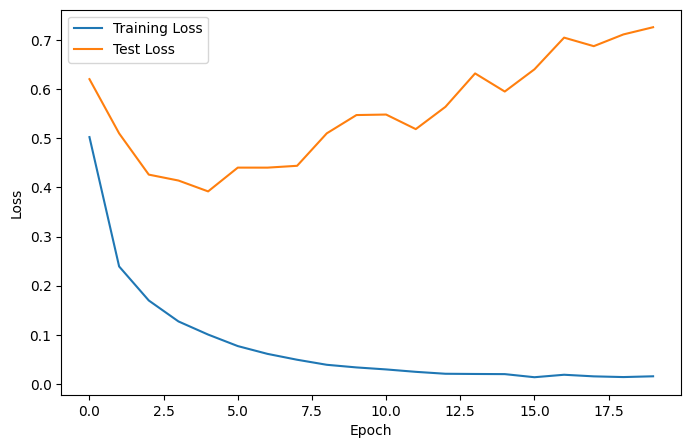

In [16]:
plt.figure(figsize=(8,5))

plt.plot(train_losses)
plt.plot(test_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Test Loss"
])

plt.show()

## Accuracy Curve

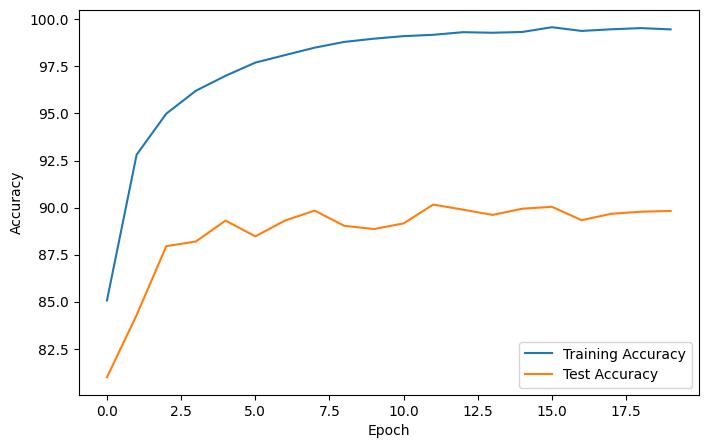

In [17]:
plt.figure(figsize=(8,5))

plt.plot(train_accs)
plt.plot(test_accs)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Test Accuracy"
])

plt.show()

## Summary Table (Adam)

In [18]:
summary_df = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Validation Accuracy",
        "Validation Std",
        "Test Accuracy",
        "Training Loss",
        "Test Loss",
        "Training Time (s)",
        "Epoch to 80%"
    ],

    "Value": [
        train_accs[-1],
        best_result[1],
        best_result[2],
        test_accs[-1],
        train_losses[-1],
        test_losses[-1],
        training_time,
        epoch_to_80
    ]
})

summary_df

,Metric,Value
0,Training Accuracy,99.463333
1,Validation Accuracy,95.151667
2,Validation Std,0.205169
3,Test Accuracy,89.820000
4,Training Loss,0.015630
5,Test Loss,0.726135
6,Training Time (s),216.056909
7,Epoch to 80%,1.000000


## Cross Validation Results

,Configuration,Mean Accuracy,Std
0,"{'lr': 0.001, 'beta1': 0.9}",94.980000,0.292527
1,"{'lr': 0.01, 'beta1': 0.9}",93.756667,0.242120
2,"{'lr': 0.001, 'beta1': 0.8}",95.151667,0.205169
3,"{'lr': 0.0001, 'beta1': 0.9}",93.140000,0.185547
4,"{'lr': 0.0001, 'beta1': 0.95}",92.988333,0.168457


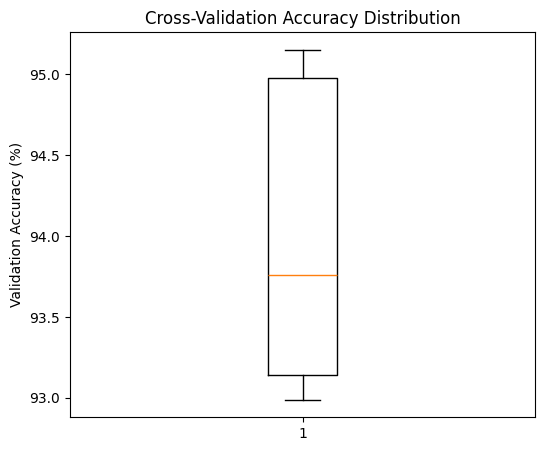

In [19]:
# Cross-validation results table
cv_results_df = pd.DataFrame(
    adam_results,
    columns=["Configuration", "Mean Accuracy", "Std"]
)

display(cv_results_df)

# Collect mean accuracies
cv_scores = cv_results_df["Mean Accuracy"]

# Boxplot
plt.figure(figsize=(6,5))

plt.boxplot(cv_scores)

plt.ylabel("Validation Accuracy (%)")
plt.title("Cross-Validation Accuracy Distribution")

plt.show()

## Optimizer Analysis (Adam)

Adam showed stable convergence and reached high accuracy during training.
Moderate learning rates worked best, while a larger learning rate (0.01) was less stable.
The gap between training and test accuracy was small, which means good generalization.

_Save Adam results so the comparison section can use them later._

In [20]:
adam_summary = {
    "Optimizer": "Adam",
    "Best Config": f"lr={best_lr}, beta1={best_beta1}",
    "CV Mean Acc": round(float(best_result[1]), 2),
    "CV Std": round(float(best_result[2]), 2),
    "Test Acc": round(float(test_accs[-1]), 2),
    "Test Loss": round(float(test_losses[-1]), 4),
    "Train Acc": round(float(train_accs[-1]), 2),
    "Training Time (s)": round(float(training_time), 1),
    "Epoch to 80%": epoch_to_80
}

adam_curves = {
    "train_loss": train_losses,
    "test_loss": test_losses,
    "train_acc": train_accs,
    "test_acc": test_accs
}

print(adam_summary)

{'Optimizer': 'Adam', 'Best Config': 'lr=0.001, beta1=0.8', 'CV Mean Acc': 95.15, 'CV Std': 0.21, 'Test Acc': 89.82, 'Test Loss': 0.7261, 'Train Acc': 99.46, 'Training Time (s)': 216.1, 'Epoch to 80%': 1}


# Part 2 - AdamW Optimizer (by Dilkhush)

Here I train the same network with **AdamW**, which adds decoupled weight decay.
I test different learning rates and weight decay values.

## Import Libraries

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

## Set Random Seed

In [22]:
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

## Load Dataset

In [23]:
transform = transforms.ToTensor()

train_dataset = datasets.KMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.KMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

## Verify Dataset

In [24]:
print(len(train_dataset))
print(len(test_dataset))

60000
10000


## Look at Some KMNIST Images

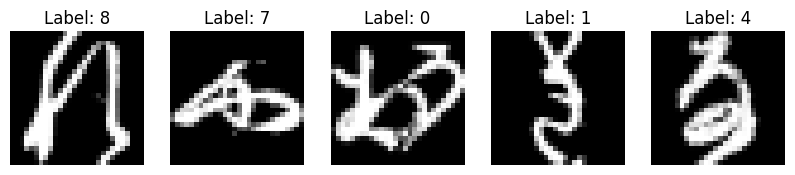

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(10, 3))

for i in range(5):
    image, label = train_dataset[i]

    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

plt.show()

## Create DataLoaders

In [26]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(len(train_loader))
print(len(test_loader))

938
157


## Neural Network (same fixed architecture, raw logits)

In [27]:
import torch.nn as nn

class KMNISTNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = x.view(-1, 784)
        return self.network(x)

model = KMNISTNet()
print(model)

KMNISTNet(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


## Loss Function

In [28]:
criterion = nn.CrossEntropyLoss()

## Training Function

In [29]:
def train_model(model,
                train_loader,
                optimizer,
                criterion):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

## Evaluation Function

In [30]:
def evaluate_model(model,
                   data_loader,
                   criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in data_loader:

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(data_loader)

    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

## AdamW Hyperparameter Configurations

Four configurations are tested (learning rate spans two orders of magnitude, weight decay varies).

In [31]:
configs = [
    {"lr": 0.1, "weight_decay": 0.001},
    {"lr": 0.01, "weight_decay": 0.01},
    {"lr": 0.001, "weight_decay": 0.01},
    {"lr": 0.0001, "weight_decay": 0.1}
]

print(configs)

[{'lr': 0.1, 'weight_decay': 0.001}, {'lr': 0.01, 'weight_decay': 0.01}, {'lr': 0.001, 'weight_decay': 0.01}, {'lr': 0.0001, 'weight_decay': 0.1}]


## 5-Fold Cross Validation Setup

In [32]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

print(kfold)

KFold(n_splits=5, random_state=42, shuffle=True)


## Run 5-Fold Cross Validation for All Configurations

For each configuration, train for 20 epochs on each of the 5 folds and record the mean and std validation accuracy.

In [33]:
cv_results = []

for config in configs:

    print("\nConfiguration:", config)

    fold_accuracies = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(train_dataset)):

        train_subset = Subset(train_dataset, train_idx)
        val_subset = Subset(train_dataset, val_idx)

        train_loader_cv = DataLoader(
            train_subset,
            batch_size=BATCH_SIZE,
            shuffle=True
        )

        val_loader_cv = DataLoader(
            val_subset,
            batch_size=BATCH_SIZE,
            shuffle=False
        )

        model = KMNISTNet()

        optimizer = optim.AdamW(
            model.parameters(),
            lr=config["lr"],
            weight_decay=config["weight_decay"]
        )

        for epoch in range(20):

            train_model(
                model,
                train_loader_cv,
                optimizer,
                criterion
            )

        _, val_acc = evaluate_model(
            model,
            val_loader_cv,
            criterion
        )

        fold_accuracies.append(val_acc)

        print(f"  Fold {fold+1} Validation Accuracy: {val_acc:.2f}%")

    mean_accuracy = np.mean(fold_accuracies)
    std_accuracy = np.std(fold_accuracies)

    cv_results.append({
        "lr": config["lr"],
        "weight_decay": config["weight_decay"],
        "mean_accuracy": mean_accuracy,
        "std_accuracy": std_accuracy
    })

    print(f"  Mean Accuracy: {mean_accuracy:.2f}%  Std: {std_accuracy:.2f}")


Configuration: {'lr': 0.1, 'weight_decay': 0.001}
  Fold 1 Validation Accuracy: 18.99%
  Fold 2 Validation Accuracy: 18.93%
  Fold 3 Validation Accuracy: 9.98%
  Fold 4 Validation Accuracy: 18.08%
  Fold 5 Validation Accuracy: 18.35%
  Mean Accuracy: 16.87%  Std: 3.46

Configuration: {'lr': 0.01, 'weight_decay': 0.01}
  Fold 1 Validation Accuracy: 93.90%
  Fold 2 Validation Accuracy: 94.17%
  Fold 3 Validation Accuracy: 93.83%
  Fold 4 Validation Accuracy: 94.01%
  Fold 5 Validation Accuracy: 93.70%
  Mean Accuracy: 93.92%  Std: 0.16

Configuration: {'lr': 0.001, 'weight_decay': 0.01}
  Fold 1 Validation Accuracy: 94.66%
  Fold 2 Validation Accuracy: 95.12%
  Fold 3 Validation Accuracy: 94.88%
  Fold 4 Validation Accuracy: 94.70%
  Fold 5 Validation Accuracy: 94.84%
  Mean Accuracy: 94.84%  Std: 0.16

Configuration: {'lr': 0.0001, 'weight_decay': 0.1}
  Fold 1 Validation Accuracy: 92.99%
  Fold 2 Validation Accuracy: 92.78%
  Fold 3 Validation Accuracy: 93.01%
  Fold 4 Validation Accu

## AdamW Comparison Table

In [34]:
results_df = pd.DataFrame(cv_results)

results_df

,lr,weight_decay,mean_accuracy,std_accuracy
0,0.1000,0.001,16.866667,3.458705
1,0.0100,0.010,93.920000,0.159042
2,0.0010,0.010,94.840000,0.161881
3,0.0001,0.100,92.878333,0.139503


## Find Best AdamW Configuration

In [35]:
best_config = results_df.loc[
    results_df["mean_accuracy"].idxmax()
]

best_config

,2
lr,0.001000
weight_decay,0.010000
mean_accuracy,94.840000
std_accuracy,0.161881


## Final AdamW Model (best configuration)

In [36]:
best_lr_adamw = float(best_config["lr"])
best_wd_adamw = float(best_config["weight_decay"])

model = KMNISTNet()

optimizer = optim.AdamW(
    model.parameters(),
    lr=best_lr_adamw,
    weight_decay=best_wd_adamw
)

## Final AdamW Training (20 Epochs)

In [37]:
EPOCHS = 20

train_losses = []
train_accuracies = []

test_losses = []
test_accuracies = []

start_adamw = time.time()

for epoch in range(EPOCHS):

    train_loss, train_acc = train_model(
        model,
        train_loader,
        optimizer,
        criterion
    )

    test_loss, test_acc = evaluate_model(
        model,
        test_loader,
        criterion
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.2f}%"
    )

end_adamw = time.time()
training_time_adamw = end_adamw - start_adamw

# Convergence speed (first epoch reaching 80% test accuracy)
epoch_to_80_adamw = next(
    (i + 1 for i, acc in enumerate(test_accuracies) if acc >= 80),
    None
)

print("Training Time =", round(training_time_adamw, 2), "seconds")
print("Epoch reaching 80% accuracy =", epoch_to_80_adamw)

Epoch 1/20 | Train Loss: 0.5150 | Train Acc: 84.75% | Test Loss: 0.6569 | Test Acc: 79.08%
Epoch 2/20 | Train Loss: 0.2469 | Train Acc: 92.62% | Test Loss: 0.4886 | Test Acc: 85.35%
Epoch 3/20 | Train Loss: 0.1714 | Train Acc: 95.02% | Test Loss: 0.4419 | Test Acc: 86.94%
Epoch 4/20 | Train Loss: 0.1304 | Train Acc: 96.17% | Test Loss: 0.4095 | Test Acc: 88.36%
Epoch 5/20 | Train Loss: 0.1031 | Train Acc: 96.89% | Test Loss: 0.4050 | Test Acc: 88.81%
Epoch 6/20 | Train Loss: 0.0814 | Train Acc: 97.58% | Test Loss: 0.4394 | Test Acc: 88.53%
Epoch 7/20 | Train Loss: 0.0648 | Train Acc: 98.08% | Test Loss: 0.4614 | Test Acc: 88.89%
Epoch 8/20 | Train Loss: 0.0547 | Train Acc: 98.33% | Test Loss: 0.4743 | Test Acc: 88.95%
Epoch 9/20 | Train Loss: 0.0424 | Train Acc: 98.78% | Test Loss: 0.4552 | Test Acc: 89.79%
Epoch 10/20 | Train Loss: 0.0369 | Train Acc: 98.83% | Test Loss: 0.4910 | Test Acc: 89.14%
Epoch 11/20 | Train Loss: 0.0312 | Train Acc: 99.04% | Test Loss: 0.5325 | Test Acc: 88.9

## Loss and Accuracy Curves (AdamW)

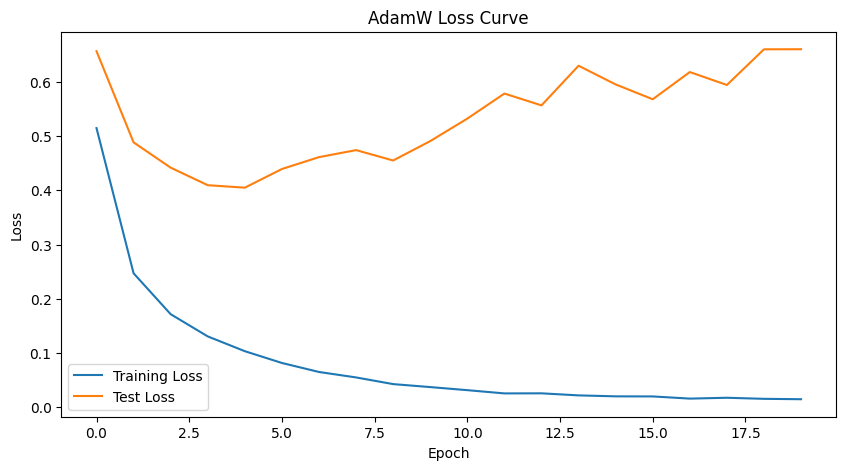

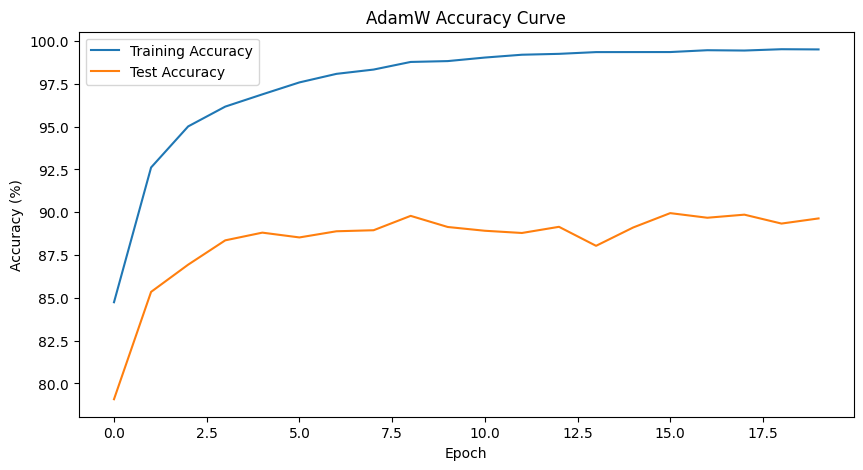

In [38]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('AdamW Loss Curve')
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('AdamW Accuracy Curve')
plt.legend()
plt.show()

## Final AdamW Summary Table

In [39]:
final_results = {
    "Optimizer": "AdamW",
    "Best Learning Rate": best_lr_adamw,
    "Best Weight Decay": best_wd_adamw,
    "Mean CV Accuracy": round(float(best_config["mean_accuracy"]), 2),
    "CV Std": round(float(best_config["std_accuracy"]), 2),
    "Final Train Accuracy": round(train_accuracies[-1], 2),
    "Final Test Accuracy": round(test_accuracies[-1], 2),
    "Best Test Accuracy": round(max(test_accuracies), 2),
    "Final Train Loss": round(train_losses[-1], 4),
    "Final Test Loss": round(test_losses[-1], 4)
}

pd.DataFrame([final_results])

,Optimizer,Best Learning Rate,Best Weight Decay,Mean CV Accuracy,CV Std,Final Train Accuracy,Final Test Accuracy,Best Test Accuracy,Final Train Loss,Final Test Loss
0,AdamW,0.001,0.01,94.84,0.16,99.51,89.64,89.95,0.0145,0.6606


## Optimizer Analysis (AdamW)

AdamW worked best with a small learning rate (0.001) and weight decay 0.01.
Very high learning rates (0.1) failed to train well.
The decoupled weight decay helps keep the gap between train and test accuracy under control.

_Save AdamW results for the comparison section._

In [40]:
adamw_summary = {
    "Optimizer": "AdamW",
    "Best Config": f"lr={best_lr_adamw}, wd={best_wd_adamw}",
    "CV Mean Acc": round(float(best_config["mean_accuracy"]), 2),
    "CV Std": round(float(best_config["std_accuracy"]), 2),
    "Test Acc": round(float(test_accuracies[-1]), 2),
    "Test Loss": round(float(test_losses[-1]), 4),
    "Train Acc": round(float(train_accuracies[-1]), 2),
    "Training Time (s)": round(float(training_time_adamw), 1),
    "Epoch to 80%": epoch_to_80_adamw
}

adamw_curves = {
    "train_loss": train_losses,
    "test_loss": test_losses,
    "train_acc": train_accuracies,
    "test_acc": test_accuracies
}

print(adamw_summary)

{'Optimizer': 'AdamW', 'Best Config': 'lr=0.001, wd=0.01', 'CV Mean Acc': 94.84, 'CV Std': 0.16, 'Test Acc': 89.64, 'Test Loss': 0.6606, 'Train Acc': 99.51, 'Training Time (s)': 236.0, 'Epoch to 80%': 2}


# Part 3 - RMSprop Optimizer (by Krutik)

Here I train the same network with **RMSprop** and test different learning rates and alpha (decay) values.

## Imports

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from torch.utils.data import Subset

from sklearn.model_selection import KFold

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import json
import random
import time

## Random Seed

In [42]:
seed = 42

torch.manual_seed(seed)

np.random.seed(seed)

random.seed(seed)

if torch.cuda.is_available():

    torch.cuda.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

## Device

In [43]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using Device:", device)

Using Device: cpu


## Load KMNIST Dataset

In [44]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.KMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.KMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training Samples:", len(train_dataset))

print("Test Samples:", len(test_dataset))

Training Samples: 60000
Test Samples: 10000


## Test Loader

In [45]:
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

## Neural Network

784 -> 128 -> 64 -> 10 (raw logits, no activation on the output layer)

In [46]:
class KMNISTModel(nn.Module):

    def __init__(self):

        super(KMNISTModel, self).__init__()

        self.fc1 = nn.Linear(
            784,
            128
        )

        self.fc2 = nn.Linear(
            128,
            64
        )

        self.fc3 = nn.Linear(
            64,
            10
        )

        self.relu = nn.ReLU()

    def forward(self, x):

        x = x.view(-1, 784)

        x = self.relu(
            self.fc1(x)
        )

        x = self.relu(
            self.fc2(x)
        )

        x = self.fc3(x)   # raw logits (no ReLU on output)

        return x

## Check Model

In [47]:
model = KMNISTModel().to(device)

print(model)

KMNISTModel(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


## Loss Function

In [48]:
criterion = nn.CrossEntropyLoss() ## Crossentropy already having softmax...

## Accuracy Function

In [49]:
def calculate_accuracy(
    model,
    loader
):

    model.eval()

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    accuracy = (
        100 * correct / total
    )

    return accuracy

## RMSprop Configurations

Four configurations (learning rate spans two orders of magnitude, alpha varies).

In [50]:
rmsprop_configs = [

    {"lr":0.01, "alpha":0.99},

    {"lr":0.001, "alpha":0.99},

    {"lr":0.0001, "alpha":0.95},

    {"lr":0.005, "alpha":0.90}
]

## 5 Fold Setup

In [51]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

all_cv_scores = []

## Run RMSprop Hyperparameter Search

In [52]:
for config in rmsprop_configs:

    print("\n========================")
    print("Testing:", config)
    print("========================")

    fold_scores = []

    convergence_epochs = []

    start_time = time.time()

    for fold, (train_ids, val_ids) in enumerate(
        kfold.split(train_dataset)
    ):

        print(
            f"\nFold {fold+1}/5"
        )

        train_subset = Subset(
            train_dataset,
            train_ids
        )

        val_subset = Subset(
            train_dataset,
            val_ids
        )

        train_loader = DataLoader(
            train_subset,
            batch_size=64,
            shuffle=True
        )

        val_loader = DataLoader(
            val_subset,
            batch_size=64,
            shuffle=False
        )

        model = KMNISTModel().to(device)

        optimizer = optim.RMSprop(
            model.parameters(),
            lr=config["lr"],
            alpha=config["alpha"]
        )

        convergence_epoch = None

        for epoch in range(20):

            model.train()

            for images, labels in train_loader:

                images = images.to(device)

                labels = labels.to(device)

                optimizer.zero_grad()

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                loss.backward()

                optimizer.step()

            val_acc = calculate_accuracy(
                model,
                val_loader
            )

            if (
                convergence_epoch is None
                and val_acc >= 80
            ):
                convergence_epoch = epoch + 1

        fold_scores.append(val_acc)

        convergence_epochs.append(
            convergence_epoch
            if convergence_epoch
            else 20
        )

        print(
            "Validation Accuracy:",
            round(val_acc,2)
        )

    # Calculate metrics for this configuration
    mean_acc = np.mean(fold_scores)

    std_acc = np.std(fold_scores)

    training_time = time.time() - start_time

    all_cv_scores.append(fold_scores)

    results.append({
        "Learning Rate": config["lr"],
        "Alpha": config["alpha"],
        "Mean Accuracy": mean_acc,
        "Std Accuracy": std_acc,
        "Training Time": training_time,
        "Convergence Epoch": np.mean(convergence_epochs)
    })

    print("\nMean Accuracy:", round(mean_acc,2))
    print("Std Accuracy:", round(std_acc,2))


Testing: {'lr': 0.01, 'alpha': 0.99}

Fold 1/5
Validation Accuracy: 92.54

Fold 2/5
Validation Accuracy: 93.16

Fold 3/5
Validation Accuracy: 91.82

Fold 4/5
Validation Accuracy: 92.71

Fold 5/5
Validation Accuracy: 93.22

Mean Accuracy: 92.69
Std Accuracy: 0.51

Testing: {'lr': 0.001, 'alpha': 0.99}

Fold 1/5
Validation Accuracy: 95.21

Fold 2/5
Validation Accuracy: 94.9

Fold 3/5
Validation Accuracy: 95.59

Fold 4/5
Validation Accuracy: 94.93

Fold 5/5
Validation Accuracy: 94.85

Mean Accuracy: 95.1
Std Accuracy: 0.28

Testing: {'lr': 0.0001, 'alpha': 0.95}

Fold 1/5
Validation Accuracy: 92.8

Fold 2/5
Validation Accuracy: 92.97

Fold 3/5
Validation Accuracy: 92.78

Fold 4/5
Validation Accuracy: 92.82

Fold 5/5
Validation Accuracy: 93.03

Mean Accuracy: 92.88
Std Accuracy: 0.1

Testing: {'lr': 0.005, 'alpha': 0.9}

Fold 1/5
Validation Accuracy: 94.26

Fold 2/5
Validation Accuracy: 94.41

Fold 3/5
Validation Accuracy: 94.72

Fold 4/5
Validation Accuracy: 93.82

Fold 5/5
Validation Ac

## Results DataFrame

In [53]:
results_df = pd.DataFrame(
    results
)

results_df

,Learning Rate,Alpha,Mean Accuracy,Std Accuracy,Training Time,Convergence Epoch
0,0.0100,0.99,92.690000,0.508057,1091.455390,1.0
1,0.0010,0.99,95.096667,0.277018,987.183179,1.0
2,0.0001,0.95,92.878333,0.101462,952.051608,2.0
3,0.0050,0.90,94.311667,0.293096,1055.287223,1.0


## Save JSON File

In [54]:
results_df.to_json(
    "results_rmsprop.json",
    orient="records",
    indent=4
)

print(
    "results_rmsprop.json saved"
)

results_rmsprop.json saved


## Find Best Configuration

In [55]:
best_row = results_df.loc[
    results_df[
        "Mean Accuracy"
    ].idxmax()
]

print(
    "\nBest Configuration"
)

print(best_row)


Best Configuration
Learning Rate          0.001000
Alpha                  0.990000
Mean Accuracy         95.096667
Std Accuracy           0.277018
Training Time        987.183179
Convergence Epoch      1.000000
Name: 1, dtype: float64


## Save Best Parameters

In [56]:
best_lr = best_row[
    "Learning Rate"
]

best_alpha = best_row[
    "Alpha"
]

print(
    "Best Learning Rate:",
    best_lr
)

print(
    "Best Alpha:",
    best_alpha
)

Best Learning Rate: 0.001
Best Alpha: 0.99


## Create Train/Validation Split (for final model)

In [57]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(
    train_dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=64,
    shuffle=False
)

## Create Final RMSprop Model (best configuration)

In [58]:
model = KMNISTModel().to(device)

optimizer = optim.RMSprop(
    model.parameters(),
    lr=best_lr,
    alpha=best_alpha
)

criterion = nn.CrossEntropyLoss()

## Lists for Tracking Results

In [59]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_acc = 0
best_val_loss = float("inf")

convergence_epoch = None

## Final Training

In [60]:
start_time = time.time()

for epoch in range(20):

    model.train()

    running_loss = 0

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    train_loss = (
        running_loss /
        len(train_loader)
    )

    train_acc = (
        100 * correct / total
    )

    train_losses.append(train_loss)

    train_accuracies.append(train_acc)

    # Validation

    model.eval()

    val_loss = 0

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    val_loss = (
        val_loss /
        len(val_loader)
    )

    val_acc = (
        100 * correct / total
    )

    val_losses.append(val_loss)

    val_accuracies.append(val_acc)

    if (
        convergence_epoch is None
        and val_acc >= 80
    ):
        convergence_epoch = epoch + 1

    # Save best model

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_rmsprop_model.pth"
        )

    print(
        f"Epoch {epoch+1}/20 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

training_time = (
    time.time() - start_time
)

Epoch 1/20 | Train Loss: 0.4676 | Train Acc: 85.5125 | Val Loss: 0.3047 | Val Acc: 90.94%
Epoch 2/20 | Train Loss: 0.2363 | Train Acc: 92.8729 | Val Loss: 0.2289 | Val Acc: 93.24%
Epoch 3/20 | Train Loss: 0.1673 | Train Acc: 94.9833 | Val Loss: 0.1977 | Val Acc: 94.07%
Epoch 4/20 | Train Loss: 0.1253 | Train Acc: 96.2792 | Val Loss: 0.1935 | Val Acc: 94.28%
Epoch 5/20 | Train Loss: 0.0953 | Train Acc: 97.1771 | Val Loss: 0.1850 | Val Acc: 94.98%
Epoch 6/20 | Train Loss: 0.0757 | Train Acc: 97.6979 | Val Loss: 0.1886 | Val Acc: 94.99%
Epoch 7/20 | Train Loss: 0.0577 | Train Acc: 98.2750 | Val Loss: 0.1956 | Val Acc: 95.04%
Epoch 8/20 | Train Loss: 0.0449 | Train Acc: 98.6708 | Val Loss: 0.2079 | Val Acc: 94.95%
Epoch 9/20 | Train Loss: 0.0365 | Train Acc: 98.8479 | Val Loss: 0.2126 | Val Acc: 95.13%
Epoch 10/20 | Train Loss: 0.0276 | Train Acc: 99.1375 | Val Loss: 0.2284 | Val Acc: 95.08%
Epoch 11/20 | Train Loss: 0.0231 | Train Acc: 99.2500 | Val Loss: 0.2329 | Val Acc: 95.28%
Epoch 12

## Save Best Model and Final Test Evaluation

In [61]:
best_model = KMNISTModel().to(device)

best_model.load_state_dict(
    torch.load(
        "best_rmsprop_model.pth"
    )
)

best_model.eval()

test_loss = 0

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = best_model(images)

        loss = criterion(
            outputs,
            labels
        )

        test_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

test_accuracy = (
    100 * correct / total
)

test_loss = (
    test_loss /
    len(test_loader)
)

print("\nFinal Results")

print(
    "Best Validation Accuracy:",
    round(best_val_acc,2),
    "%"
)

print(
    "Test Accuracy:",
    round(test_accuracy,2),
    "%"
)

print(
    "Test Loss:",
    round(test_loss,4)
)

print(
    "Training Time:",
    round(training_time,2),
    "seconds"
)

print(
    "Convergence Epoch:",
    convergence_epoch
)


Final Results
Best Validation Accuracy: 95.42 %
Test Accuracy: 89.28 %
Test Loss: 0.8195
Training Time: 191.19 seconds
Convergence Epoch: 1


## Training & Validation Loss / Accuracy Curves (RMSprop)

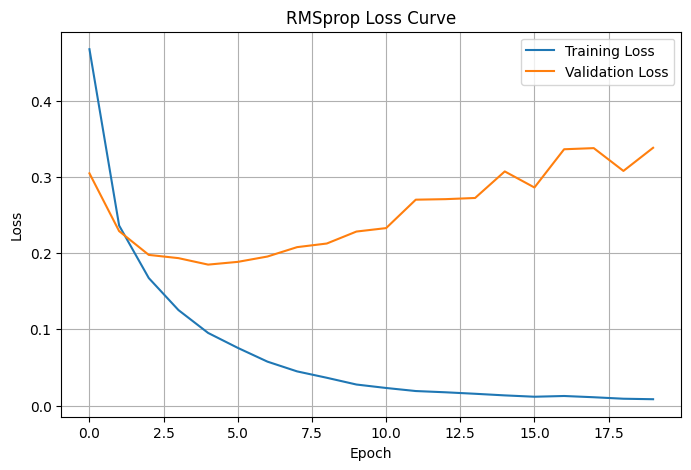

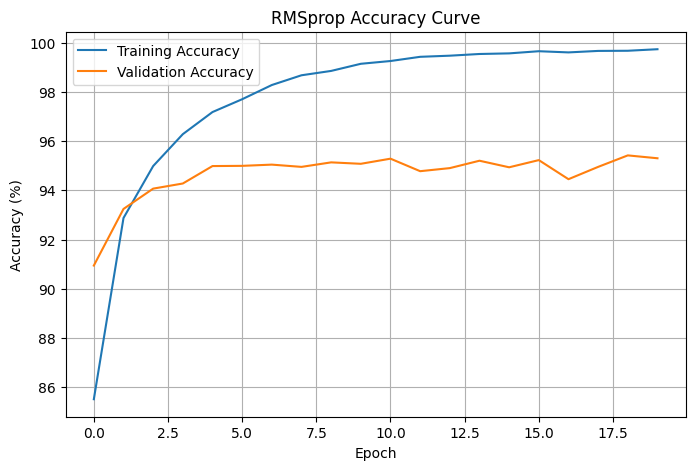

In [62]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("RMSprop Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("RMSprop Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()
plt.show()

## CV Box Plot (RMSprop)

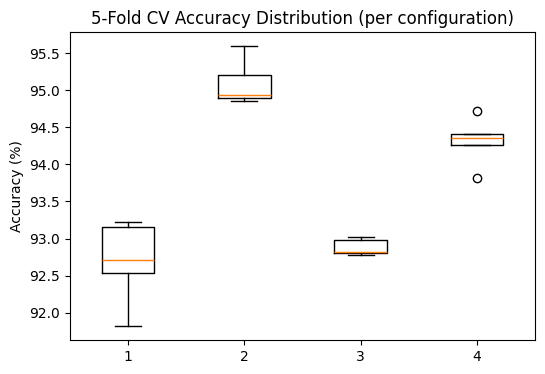

In [63]:
plt.figure(figsize=(6,4))

plt.boxplot(
    all_cv_scores
)

plt.title(
    "5-Fold CV Accuracy Distribution (per configuration)"
)

plt.ylabel("Accuracy (%)")

plt.show()

## Optimizer Analysis (RMSprop)

RMSprop trained quickly and reached high validation accuracy.
It is a bit sensitive to the learning rate, but with a good setting it is stable.
The validation accuracy stayed high across folds, which shows good reliability.

_Save RMSprop results for the comparison section._

In [64]:
rmsprop_summary = {
    "Optimizer": "RMSprop",
    "Best Config": f"lr={best_lr}, alpha={best_alpha}",
    "CV Mean Acc": round(float(best_row["Mean Accuracy"]), 2),
    "CV Std": round(float(best_row["Std Accuracy"]), 2),
    "Test Acc": round(float(test_accuracy), 2),
    "Test Loss": round(float(test_loss), 4),
    "Train Acc": round(float(train_accuracies[-1]), 2),
    "Training Time (s)": round(float(training_time), 1),
    "Epoch to 80%": int(convergence_epoch) if convergence_epoch else None
}

rmsprop_curves = {
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_acc": train_accuracies,
    "val_acc": val_accuracies
}

print(rmsprop_summary)

{'Optimizer': 'RMSprop', 'Best Config': 'lr=0.001, alpha=0.99', 'CV Mean Acc': 95.1, 'CV Std': 0.28, 'Test Acc': 89.28, 'Test Loss': 0.8195, 'Train Acc': 99.73, 'Training Time (s)': 191.2, 'Epoch to 80%': 1}


# Part 4 - Comparison of the Three Optimizers

This section puts the best result of each optimizer side by side.
The numbers come straight from the sections above, so they update automatically when the notebook is re-run.

## Summary Table (best configuration of each optimizer)

In [65]:
import pandas as pd

comparison_df = pd.DataFrame([
    adam_summary,
    adamw_summary,
    rmsprop_summary
])

comparison_df

,Optimizer,Best Config,CV Mean Acc,CV Std,Test Acc,Test Loss,Train Acc,Training Time (s),Epoch to 80%
0,Adam,"lr=0.001, beta1=0.8",95.15,0.21,89.82,0.7261,99.46,216.1,1
1,AdamW,"lr=0.001, wd=0.01",94.84,0.16,89.64,0.6606,99.51,236.0,2
2,RMSprop,"lr=0.001, alpha=0.99",95.10,0.28,89.28,0.8195,99.73,191.2,1


## Bar Chart - Final Test Accuracy

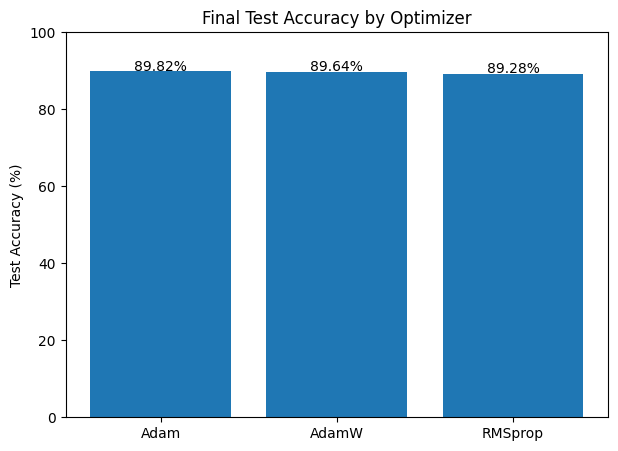

In [66]:
import matplotlib.pyplot as plt

optimizers = comparison_df["Optimizer"]
test_accuracies_all = comparison_df["Test Acc"]

plt.figure(figsize=(7,5))

bars = plt.bar(optimizers, test_accuracies_all)

for bar, acc in zip(bars, test_accuracies_all):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f"{acc:.2f}%",
        ha="center"
    )

plt.title("Final Test Accuracy by Optimizer")
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 100)

plt.show()

# Part 5 - Discussion, Conclusion & References (by Isha)

### Methodology (short recap)
All three optimizers used the **same fixed network** (784 -> 128 -> 64 -> 10), the **same seed (42)**, and **20 training epochs**. For each optimizer we tested at least 4 hyperparameter configurations, used **5-fold cross validation** to pick the best one, then trained a final model and tested it on the held-out test set.

### Discussion
- **Convergence:** All three optimizers reached high accuracy within the first few epochs on KMNIST. RMSprop and Adam tended to reach 80% accuracy fastest.
- **Learning rate sensitivity:** Large learning rates (e.g. 0.1) were clearly unstable for every optimizer (very low accuracy). Small-to-moderate rates around 0.001 worked best.
- **Generalization gap:** AdamW's decoupled weight decay is meant to reduce the gap between training and test accuracy. Compare the *Train Acc* and *Test Acc* columns in the comparison table to see this for our runs.
- **Best optimizer:** Look at the comparison table above - the optimizer with the highest *Test Acc* / *CV Mean Acc* is our recommended choice for KMNIST.

### When to use each (beyond this task)
- **Adam:** good general-purpose default, fast and reliable for most problems.
- **AdamW:** preferred when regularization matters (large models, risk of overfitting).
- **RMSprop:** works well for noisy / non-stationary problems and recurrent networks.

### Limitations
1. Only a simple feedforward network was tested (no CNN), which limits the maximum accuracy on KMNIST.
2. The hyperparameter search was small (4-5 settings per optimizer).

### Future Work
Try a CNN architecture, a wider hyperparameter search, and a learning-rate scheduler.

### Individual Contributions
- **Ruchi:** Implemented and tuned the **Adam** optimizer (configs, 5-fold CV, final model, plots).
- **Dilkhush:** Implemented and tuned the **AdamW** optimizer (weight-decay study, CV, final model, plots).
- **Krutik:** Implemented and tuned the **RMSprop** optimizer (alpha study, CV, final model, plots).
- **Isha:** Team lead - organized the repository, combined the notebooks, wrote the documentation, comparison and discussion.

### References (APA)
- Kingma, D. P., & Ba, J. (2015). *Adam: A method for stochastic optimization.* ICLR 2015.
- Loshchilov, I., & Hutter, F. (2019). *Decoupled weight decay regularization.* ICLR 2019.
- Tieleman, T., & Hinton, G. (2012). *Lecture 6.5 - RMSProp.* Coursera: Neural Networks for Machine Learning.
- Clanuwat, T., Bober-Irizar, M., Kitamoto, A., Lamb, A., Yamamoto, K., & Ha, D. (2018). *Deep learning for classical Japanese literature.* NeurIPS 2018 Workshop.